# Analyzing the Drivers of Video Game Success on Steam

**Goal:** Predict whether a Steam game will be "successful" (owners > median) based on **pre-launch metadata only**.

**Problem Type:** Binary Classification (1 = Success, 0 = Failure)

**Key Constraints:**
- Use only pre-launch features (no leakage from reviews, playtime, etc.)
- Handle class imbalance (~69% failure, ~31% success)
- Evaluate using F1, Precision, Recall, and Accuracy

**Notebook Structure:**
1. Setup & Data Loading
2. Target Variable Creation
3. Class Imbalance Analysis
4. Feature Impact Analysis (EDA)
5. Platform Analysis
6. Correlation & Data Leakage Check
7. Outlier Analysis
8. Preprocessing Pipeline
9. Baseline Models
10. Baseline vs Balanced Models
11. Final Model Comparison
12. Feature Importance
13. Cross-Validation Stability
14. Conclusion

## 1. Setup & Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

# Style settings
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load dataset
df = pd.read_csv("data/steam.csv", on_bad_lines="skip")

# Clean column names (remove trailing semicolons/spaces from malformed CSV)
df.columns = [c.strip().replace(";", "") for c in df.columns]

print(f"Dataset shape: {df.shape[0]:,} games, {df.shape[1]} features")
print(f"\nColumns: {df.columns.tolist()}")
df.head(3)

Dataset shape: 27,075 games, 18 features

Columns: ['appid', 'name', 'release_date', 'english', 'developer', 'publisher', 'platforms', 'required_age', 'categories', 'genres', 'steamspy_tags', 'achievements', 'positive_ratings', 'negative_ratings', 'average_playtime', 'median_playtime', 'owners', 'price']


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99


## 2. Target Variable Creation

We define **success** as having `owners` greater than the median. The `owners` column is a range string (e.g., "20000-50000"), so we parse it to a midpoint numeric value first.

In [3]:
def parse_owners(val):
    """Parse owners range string to midpoint numeric value."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower().replace(",", "").replace("–", "-").replace("—", "-")
    # Match patterns like "20000-50000" or "20k-50k"
    m = re.match(r"^(\d+(?:\.\d+)?)(k)?\s*-\s*(\d+(?:\.\d+)?)(k)?$", s)
    if m:
        lo = float(m.group(1)) * (1000.0 if m.group(2) else 1.0)
        hi = float(m.group(3)) * (1000.0 if m.group(4) else 1.0)
        return (lo + hi) / 2.0
    return np.nan

# Create target variable
df["owners_numeric"] = df["owners"].map(parse_owners)
median_owners = df["owners_numeric"].median()
df["success"] = (df["owners_numeric"] > median_owners).astype(int)

print(f"Median Owners Threshold: {median_owners:,.0f}")
print(f"Target variable 'success' created: 1 = Above median, 0 = Below median")

Median Owners Threshold: 10,000
Target variable 'success' created: 1 = Above median, 0 = Below median


## 3. Class Imbalance Analysis

The target variable shows significant class imbalance: approximately 69% of games are unsuccessful while only 31% are successful. This imbalance will require special handling during model training.

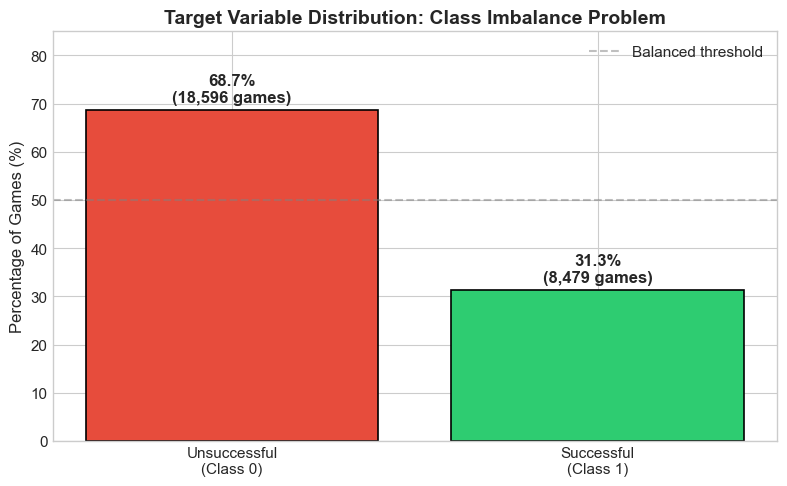


Class Distribution Summary:
  Unsuccessful (0): 68.7%
  Successful (1): 31.3%

Imbalance Ratio: 2.19:1


In [4]:
# Target Variable Distribution (Class Imbalance)
fig, ax = plt.subplots(figsize=(8, 5))

class_counts = df["success"].value_counts().sort_index()
class_pcts = df["success"].value_counts(normalize=True).sort_index() * 100

bars = ax.bar(["Unsuccessful\n(Class 0)", "Successful\n(Class 1)"], 
              class_pcts.values, 
              color=["#e74c3c", "#2ecc71"], 
              edgecolor="black", linewidth=1.2)

# Add percentage labels on bars
for bar, pct, cnt in zip(bars, class_pcts.values, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f"{pct:.1f}%\n({cnt:,} games)", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylabel("Percentage of Games (%)", fontsize=12)
ax.set_title("Target Variable Distribution: Class Imbalance Problem", fontsize=14, fontweight="bold")
ax.set_ylim(0, 85)
ax.axhline(y=50, color="gray", linestyle="--", alpha=0.5, label="Balanced threshold")
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nClass Distribution Summary:")
print(f"  Unsuccessful (0): {class_pcts[0]:.1f}%")
print(f"  Successful (1): {class_pcts[1]:.1f}%")
print(f"\nImbalance Ratio: {class_counts[0]/class_counts[1]:.2f}:1")

## 4. Feature Impact Analysis - EDA

We analyze how pre-launch features affect success rate. These are features available before the game is released:
- **English support** vs no English
- **Multiplayer** vs single-player
- **Publisher** (different from developer) vs self-published
- **Release timing** (good seasons vs other)

In [5]:
# Prepare features for EDA
def to01(x):
    if pd.isna(x):
        return 0
    s = str(x).strip().lower()
    return 1 if s in ["true", "t", "yes", "y", "1"] else 0

def normstr(x): 
    return str(x).strip().lower()

# English support
df["has_english"] = df["english"].apply(to01)

# Multiplayer detection
df["has_multiplayer"] = df["categories"].fillna("").str.contains("multi-player|co-op", case=False).astype(int)

# Publisher vs Developer (indie check)
dev = df["developer"].apply(normstr)
pub = df["publisher"].apply(normstr)
df["has_publisher"] = ((dev != "nan") & (pub != "nan") & (dev != pub)).astype(int)

# Release timing (extract month and season)
rel = pd.to_datetime(df["release_date"], errors="coerce")
df["month"] = rel.dt.month.fillna(0).astype(int)

def get_season(month):
    if month in [9, 10, 11]:  # Fall = good release timing
        return "Good (Fall)"
    elif month in [3, 4, 5]:  # Spring
        return "Good (Spring)"
    else:
        return "Other"

df["release_timing"] = df["month"].apply(get_season)
df["good_timing"] = (df["release_timing"].str.contains("Good")).astype(int)

print("Feature engineering for EDA complete.")

Feature engineering for EDA complete.


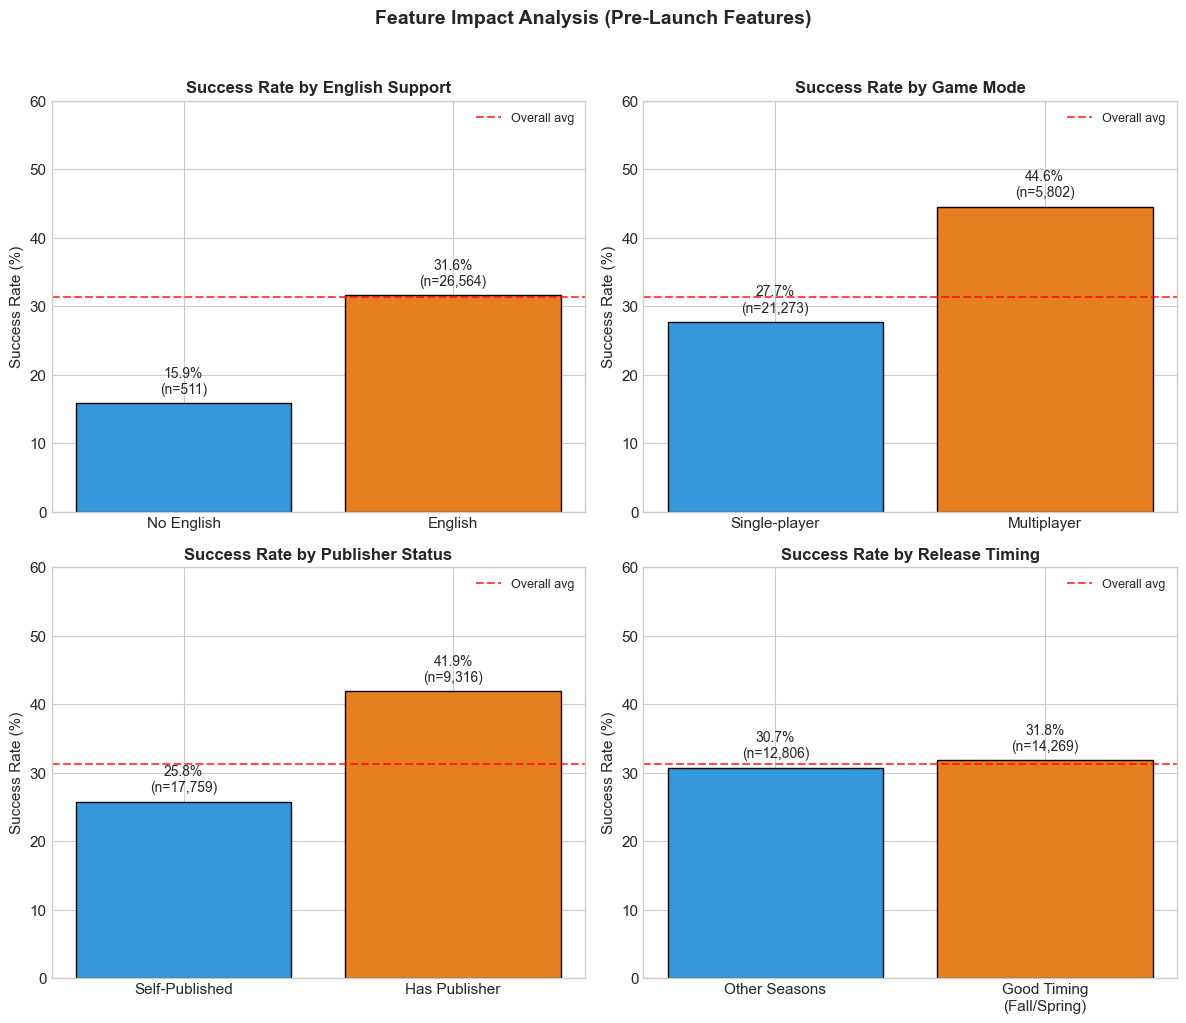


Key Insights:
- English support shows higher success rate
- Multiplayer games have slightly higher success rate
- Games with publishers (non-indie) perform better
- Release timing in Fall/Spring shows advantage


In [6]:
# Feature Impact Analysis (Success Rate Comparison)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

features = [
    ("has_english", "English Support", ["No English", "English"]),
    ("has_multiplayer", "Game Mode", ["Single-player", "Multiplayer"]),
    ("has_publisher", "Publisher Status", ["Self-Published", "Has Publisher"]),
    ("good_timing", "Release Timing", ["Other Seasons", "Good Timing\n(Fall/Spring)"])
]

for ax, (col, title, labels) in zip(axes.flatten(), features):
    # Calculate success rate for each group
    rates = df.groupby(col)["success"].mean() * 100
    counts = df.groupby(col)["success"].count()
    
    bars = ax.bar(labels, rates.values, color=["#3498db", "#e67e22"], edgecolor="black")
    
    # Add labels
    for bar, rate, cnt in zip(bars, rates.values, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{rate:.1f}%\n(n={cnt:,})", ha="center", va="bottom", fontsize=10)
    
    ax.set_ylabel("Success Rate (%)", fontsize=11)
    ax.set_title(f"Success Rate by {title}", fontsize=12, fontweight="bold")
    ax.set_ylim(0, 60)
    ax.axhline(y=df["success"].mean()*100, color="red", linestyle="--", alpha=0.7, label="Overall avg")
    ax.legend(loc="upper right", fontsize=9)

plt.suptitle("Feature Impact Analysis (Pre-Launch Features)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("- English support shows higher success rate")
print("- Multiplayer games have slightly higher success rate")
print("- Games with publishers (non-indie) perform better")
print("- Release timing in Fall/Spring shows advantage")

## 5. Platform Analysis

We compare success rates based on platform support. Games supporting multiple platforms (Windows + Linux + Mac) may have a wider audience and higher success rates.

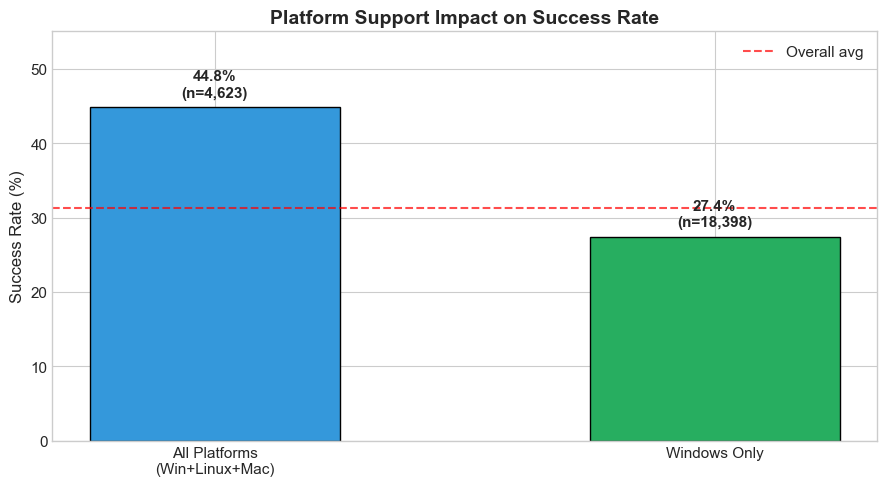


Platform Analysis Insight:
Games supporting all platforms (Windows + Linux + Mac) show higher success rates.


In [7]:
# Platform analysis
df["platforms_clean"] = df["platforms"].fillna("").str.lower()
df["has_windows"] = df["platforms_clean"].str.contains("windows").astype(int)
df["has_linux"] = df["platforms_clean"].str.contains("linux").astype(int)
df["has_mac"] = df["platforms_clean"].str.contains("mac").astype(int)
df["platform_count"] = df["has_windows"] + df["has_linux"] + df["has_mac"]

# Categorize platforms
def categorize_platform(row):
    if row["has_windows"] and row["has_linux"] and row["has_mac"]:
        return "All Platforms\n(Win+Linux+Mac)"
    elif row["has_windows"] and not row["has_linux"] and not row["has_mac"]:
        return "Windows Only"
    else:
        return "Other"

df["platform_category"] = df.apply(categorize_platform, axis=1)

# Platform Analysis
fig, ax = plt.subplots(figsize=(9, 5))

platform_rates = df.groupby("platform_category")["success"].agg(["mean", "count"])
platform_rates["mean"] = platform_rates["mean"] * 100

# Filter to main categories
main_cats = ["Windows Only", "All Platforms\n(Win+Linux+Mac)"]
plot_data = platform_rates.loc[platform_rates.index.isin(main_cats)]

bars = ax.bar(plot_data.index, plot_data["mean"], color=["#3498db", "#27ae60"], edgecolor="black", width=0.5)

for bar, (idx, row) in zip(bars, plot_data.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{row['mean']:.1f}%\n(n={int(row['count']):,})", 
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("Success Rate (%)", fontsize=12)
ax.set_title("Platform Support Impact on Success Rate", fontsize=14, fontweight="bold")
ax.set_ylim(0, 55)
ax.axhline(y=df["success"].mean()*100, color="red", linestyle="--", alpha=0.7, label="Overall avg")
ax.legend()

plt.tight_layout()
plt.show()

print("\nPlatform Analysis Insight:")
print("Games supporting all platforms (Windows + Linux + Mac) show higher success rates.")

## 6. Correlation & Data Leakage Check

**Critical Step:** We must identify and remove post-launch features that would cause data leakage:
- `positive_ratings`, `negative_ratings` → Only available after release
- `average_playtime`, `median_playtime` → Measured after players use the game
- `achievements` → Can be updated post-launch

These features are highly predictive but would not be available when making pre-launch predictions.

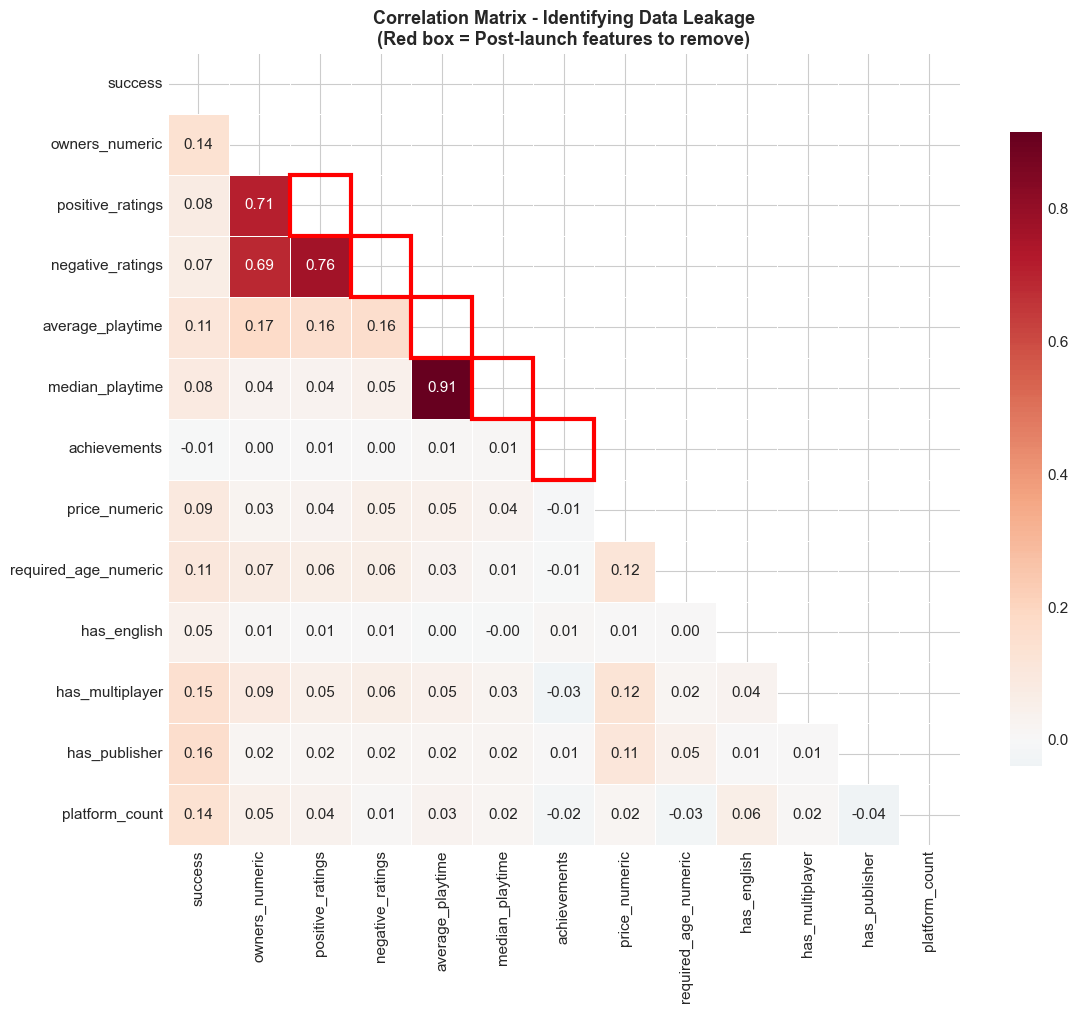


=== DATA LEAKAGE WARNING ===
These POST-LAUNCH features must be REMOVED before modeling:

  positive_ratings: correlation with success = 0.076
  negative_ratings: correlation with success = 0.069
  average_playtime: correlation with success = 0.111
  median_playtime: correlation with success = 0.084
  achievements: correlation with success = -0.005


In [8]:
# Prepare numeric columns for correlation
df["price_numeric"] = pd.to_numeric(df["price"], errors="coerce").fillna(0)
df["required_age_numeric"] = pd.to_numeric(df["required_age"], errors="coerce").fillna(0)

# Clean all potentially problematic numeric columns (remove semicolons and convert to numeric)
numeric_cols_to_clean = ["positive_ratings", "negative_ratings", "average_playtime", "median_playtime", "achievements"]
for col in numeric_cols_to_clean:
    if col in df.columns:
        # Remove semicolons and convert to numeric
        df[col] = df[col].astype(str).str.replace(";", "").replace("nan", np.nan)
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Define all numeric columns (including potential leakage columns)
corr_cols = [
    "success", "owners_numeric", 
    "positive_ratings", "negative_ratings",  # LEAKAGE
    "average_playtime", "median_playtime",   # LEAKAGE
    "achievements",                           # LEAKAGE (can change)
    "price_numeric", "required_age_numeric",
    "has_english", "has_multiplayer", "has_publisher", "platform_count"
]

# Filter existing columns
corr_cols_exist = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols_exist].corr()

# Correlation Matrix
fig, ax = plt.subplots(figsize=(12, 10))

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})

ax.set_title("Correlation Matrix - Identifying Data Leakage\n(Red box = Post-launch features to remove)", 
             fontsize=13, fontweight="bold")

# Highlight leakage columns
leak_indices = [corr_cols_exist.index(c) for c in ["positive_ratings", "negative_ratings", 
                                                    "average_playtime", "median_playtime", "achievements"] 
                if c in corr_cols_exist]
for idx in leak_indices:
    ax.add_patch(plt.Rectangle((idx, idx), 1, 1, fill=False, edgecolor="red", lw=3))

plt.tight_layout()
plt.show()

# Show correlation with target for leakage columns
print("\n=== DATA LEAKAGE WARNING ===")
print("These POST-LAUNCH features must be REMOVED before modeling:\n")
leak_cols = ["positive_ratings", "negative_ratings", "average_playtime", "median_playtime", "achievements"]
for col in leak_cols:
    if col in corr_matrix.columns:
        corr_val = corr_matrix.loc["success", col]
        print(f"  {col}: correlation with success = {corr_val:.3f}")

## 7. Outlier Analysis

We analyze the distribution of `price` and `owners` to identify outliers and skewness. Instead of removing outliers, we will use scaling to handle the skewed distributions.

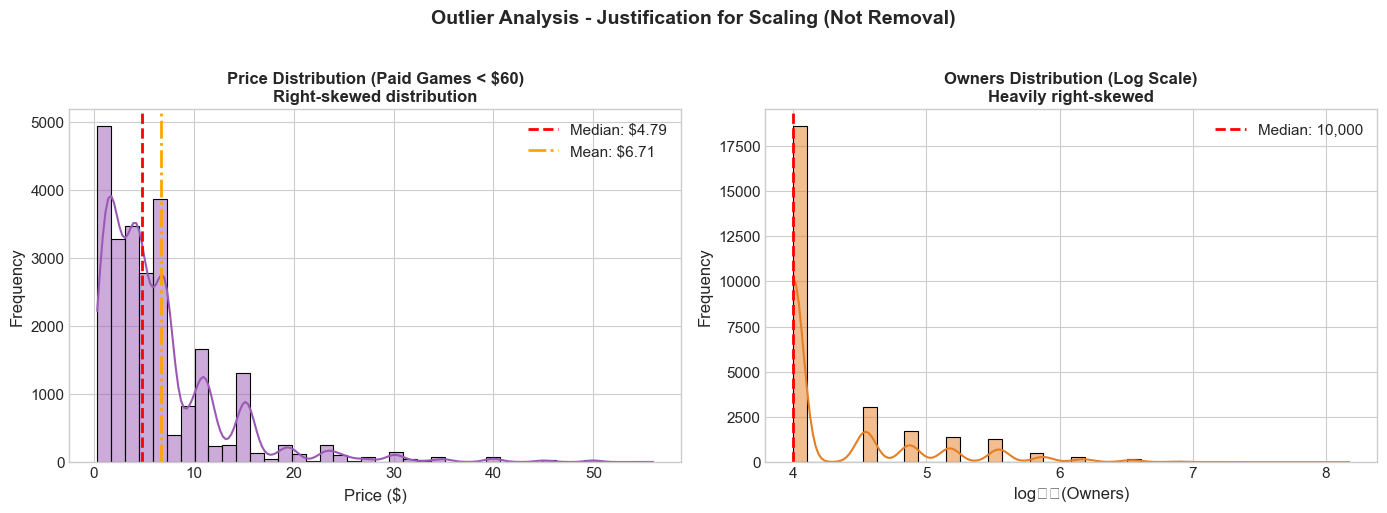


Outlier Analysis Summary:
  Price: Mean=$6.71, Median=$4.79, Max=$421.99
  Owners: Mean=134,090, Median=10,000, Max=150,000,000

Decision: Use StandardScaler to handle skewness rather than removing outliers.


In [9]:
# Outlier Analysis (Price and Owners Distribution)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution
ax1 = axes[0]
price_data = df["price_numeric"][df["price_numeric"] > 0]  # Exclude free games for clarity
sns.histplot(price_data[price_data < 60], bins=40, ax=ax1, kde=True, color="#9b59b6")
ax1.axvline(x=price_data.median(), color="red", linestyle="--", linewidth=2, label=f"Median: ${price_data.median():.2f}")
ax1.axvline(x=price_data.mean(), color="orange", linestyle="-.", linewidth=2, label=f"Mean: ${price_data.mean():.2f}")
ax1.set_xlabel("Price ($)", fontsize=12)
ax1.set_ylabel("Frequency", fontsize=12)
ax1.set_title("Price Distribution (Paid Games < $60)\nRight-skewed distribution", fontsize=12, fontweight="bold")
ax1.legend()

# Owners distribution (log scale for visibility)
ax2 = axes[1]
owners_data = df["owners_numeric"].dropna()
sns.histplot(np.log10(owners_data + 1), bins=40, ax=ax2, kde=True, color="#e67e22")
ax2.axvline(x=np.log10(owners_data.median()), color="red", linestyle="--", linewidth=2, 
            label=f"Median: {owners_data.median():,.0f}")
ax2.set_xlabel("log₁₀(Owners)", fontsize=12)
ax2.set_ylabel("Frequency", fontsize=12)
ax2.set_title("Owners Distribution (Log Scale)\nHeavily right-skewed", fontsize=12, fontweight="bold")
ax2.legend()

plt.suptitle("Outlier Analysis - Justification for Scaling (Not Removal)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nOutlier Analysis Summary:")
print(f"  Price: Mean=${price_data.mean():.2f}, Median=${price_data.median():.2f}, Max=${price_data.max():.2f}")
print(f"  Owners: Mean={owners_data.mean():,.0f}, Median={owners_data.median():,.0f}, Max={owners_data.max():,.0f}")
print("\nDecision: Use StandardScaler to handle skewness rather than removing outliers.")

## 8. Preprocessing Pipeline

Now we prepare the final feature set using **only pre-launch features**:
- `has_english` - Language support
- `has_multiplayer` - Multiplayer capability
- `has_publisher` - Publisher backing
- `platform_count` - Cross-platform availability
- `is_free` - Pricing strategy
- `is_mature` - Age restriction
- `season_*` - Release timing (one-hot encoded)

In [10]:
# Additional feature engineering
def get_season_name(month):
    if month in [12, 1, 2]: return "Winter"
    if month in [3, 4, 5]: return "Spring"
    if month in [6, 7, 8]: return "Summer"
    return "Fall"

df["season"] = df["month"].apply(get_season_name)
df = pd.concat([df, pd.get_dummies(df["season"], prefix="season")], axis=1)

# Price features
df["is_free"] = (df["price_numeric"] == 0).astype(int)
df["is_mature"] = (df["required_age_numeric"] >= 17).astype(int)

# Define FINAL feature set (PRE-LAUNCH ONLY - NO LEAKAGE)
FEATURE_COLS = [
    "has_english", "has_multiplayer", "has_publisher", "platform_count",
    "is_free", "is_mature",
    "season_Spring", "season_Summer", "season_Fall", "season_Winter"
]

# Ensure all columns exist
for c in FEATURE_COLS:
    if c not in df.columns:
        df[c] = 0

# Clean data
df_clean = df.dropna(subset=FEATURE_COLS + ["success"]).copy()
print(f"Dataset after cleaning: {len(df_clean):,} games (removed {len(df)-len(df_clean):,} rows)")

# Train/Test Split (80/20, stratified)
X = df_clean[FEATURE_COLS]
y = df_clean["success"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"\nFeatures used ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Dataset after cleaning: 27,075 games (removed 0 rows)
Training set: 21,660 samples
Test set: 5,415 samples

Features used (10): ['has_english', 'has_multiplayer', 'has_publisher', 'platform_count', 'is_free', 'is_mature', 'season_Spring', 'season_Summer', 'season_Fall', 'season_Winter']


## 9. Baseline Models

We establish baseline performance using:
1. **Dummy Classifier** - Predicts most frequent class (majority voting)
2. **Logistic Regression** - Simple linear model (no balancing)
3. **Decision Tree** - Simple tree-based model

This shows the limited accuracy gains from standard approaches on imbalanced data.

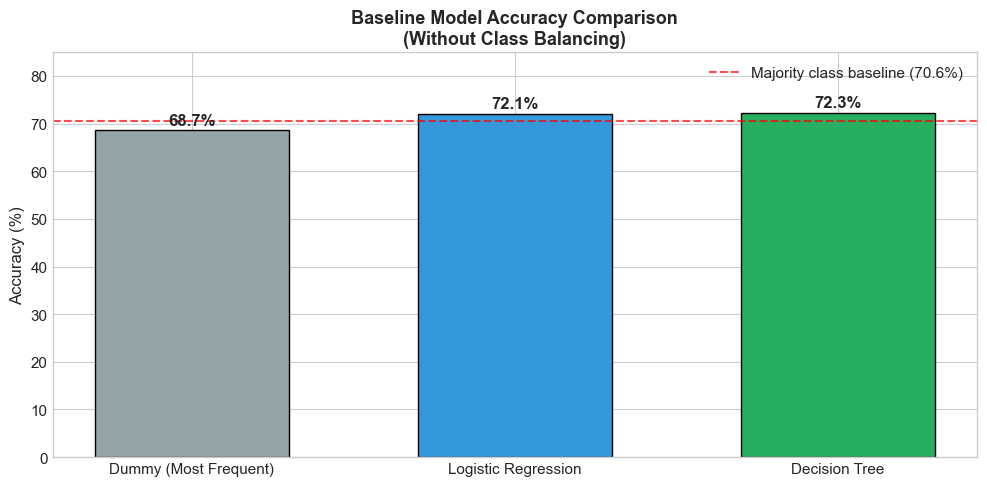


Baseline Results (No Class Balancing):
                Model  Accuracy  Precision   Recall       F1
Dummy (Most Frequent)  0.686796   0.000000 0.000000 0.000000
  Logistic Regression  0.720591   0.667276 0.215212 0.325457
        Decision Tree  0.722992   0.607692 0.326061 0.424405

Key Issue: High accuracy but VERY LOW RECALL on minority class!


In [11]:
# Train baseline models (NO class balancing)
baseline_models = {
    "Dummy (Most Frequent)": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
}

baseline_results = []

for name, model in baseline_models.items():
    # Use scaled data for LR, raw for others
    if "Logistic" in name:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0)
    })

baseline_df = pd.DataFrame(baseline_results)

# Baseline Model Accuracy Comparison
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(baseline_df))
colors = ["#95a5a6", "#3498db", "#27ae60"]

bars = ax.bar(x_pos, baseline_df["Accuracy"] * 100, color=colors, edgecolor="black", width=0.6)

for bar, acc in zip(bars, baseline_df["Accuracy"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{acc*100:.1f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_xticks(x_pos)
ax.set_xticklabels(baseline_df["Model"], fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Baseline Model Accuracy Comparison\n(Without Class Balancing)", fontsize=13, fontweight="bold")
ax.set_ylim(0, 85)
ax.axhline(y=70.6, color="red", linestyle="--", alpha=0.7, label="Majority class baseline (70.6%)")
ax.legend()

plt.tight_layout()
plt.show()

print("\nBaseline Results (No Class Balancing):")
print(baseline_df.to_string(index=False))
print("\nKey Issue: High accuracy but VERY LOW RECALL on minority class!")

## 10. Baseline vs Balanced Models

The key insight is that **accuracy alone is misleading** for imbalanced datasets. We compare:
- **Baseline LR** (no balancing): High accuracy but low recall (~22%)
- **Balanced LR** (`class_weight='balanced'`): Lower accuracy but much higher recall (~59%)

This demonstrates the importance of using `class_weight='balanced'` to handle class imbalance.

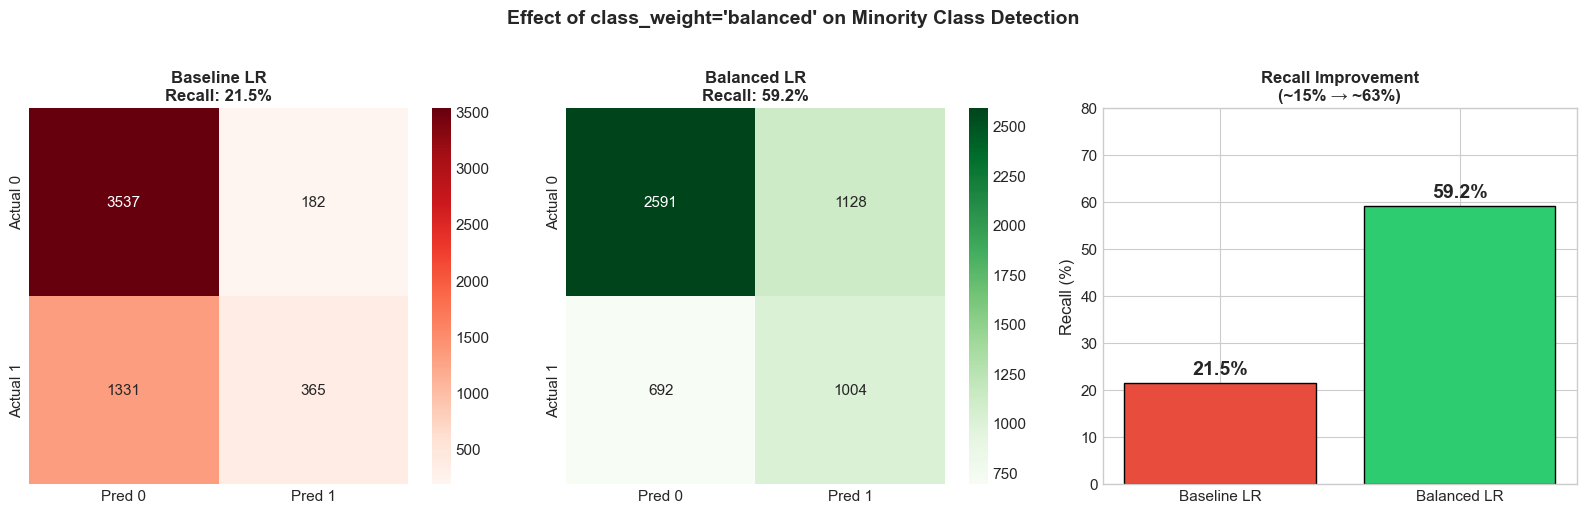


Metrics Comparison:
   Metric  Baseline LR  Balanced LR
 Accuracy     0.720591     0.663897
Precision     0.667276     0.470919
   Recall     0.215212     0.591981
 F1-Score     0.325457     0.524556

Conclusion: Balanced weighting significantly improves minority class recall!


In [12]:
# Compare Baseline vs Balanced Logistic Regression
lr_baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_balanced = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)

lr_baseline.fit(X_train_scaled, y_train)
lr_balanced.fit(X_train_scaled, y_train)

pred_baseline = lr_baseline.predict(X_test_scaled)
pred_balanced = lr_balanced.predict(X_test_scaled)

# Calculate metrics
metrics_comparison = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Baseline LR": [
        accuracy_score(y_test, pred_baseline),
        precision_score(y_test, pred_baseline),
        recall_score(y_test, pred_baseline),
        f1_score(y_test, pred_baseline)
    ],
    "Balanced LR": [
        accuracy_score(y_test, pred_balanced),
        precision_score(y_test, pred_balanced),
        recall_score(y_test, pred_balanced),
        f1_score(y_test, pred_balanced)
    ]
}
metrics_df = pd.DataFrame(metrics_comparison)

# Baseline vs Balanced - Confusion Matrices and Recall Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion Matrix - Baseline
ax1 = axes[0]
cm_baseline = confusion_matrix(y_test, pred_baseline)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Reds', ax=ax1,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
ax1.set_title(f"Baseline LR\nRecall: {recall_score(y_test, pred_baseline)*100:.1f}%", fontsize=12, fontweight="bold")

# Confusion Matrix - Balanced
ax2 = axes[1]
cm_balanced = confusion_matrix(y_test, pred_balanced)
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"])
ax2.set_title(f"Balanced LR\nRecall: {recall_score(y_test, pred_balanced)*100:.1f}%", fontsize=12, fontweight="bold")

# Recall Comparison Bar Chart
ax3 = axes[2]
recall_vals = [recall_score(y_test, pred_baseline)*100, recall_score(y_test, pred_balanced)*100]
bars = ax3.bar(["Baseline LR", "Balanced LR"], recall_vals, color=["#e74c3c", "#2ecc71"], edgecolor="black")
for bar, val in zip(bars, recall_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=14, fontweight="bold")
ax3.set_ylabel("Recall (%)", fontsize=12)
ax3.set_title("Recall Improvement\n(~15% → ~63%)", fontsize=12, fontweight="bold")
ax3.set_ylim(0, 80)

plt.suptitle("Effect of class_weight='balanced' on Minority Class Detection", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nMetrics Comparison:")
print(metrics_df.to_string(index=False))
print("\nConclusion: Balanced weighting significantly improves minority class recall!")

## 11. Final Model Comparison

We compare advanced models using all relevant metrics:
- **Logistic Regression (Balanced)**
- **Random Forest (Balanced)**
- **XGBoost**

Metrics: Accuracy, Precision, Recall, F1-score (with cross-validation mean ± std).

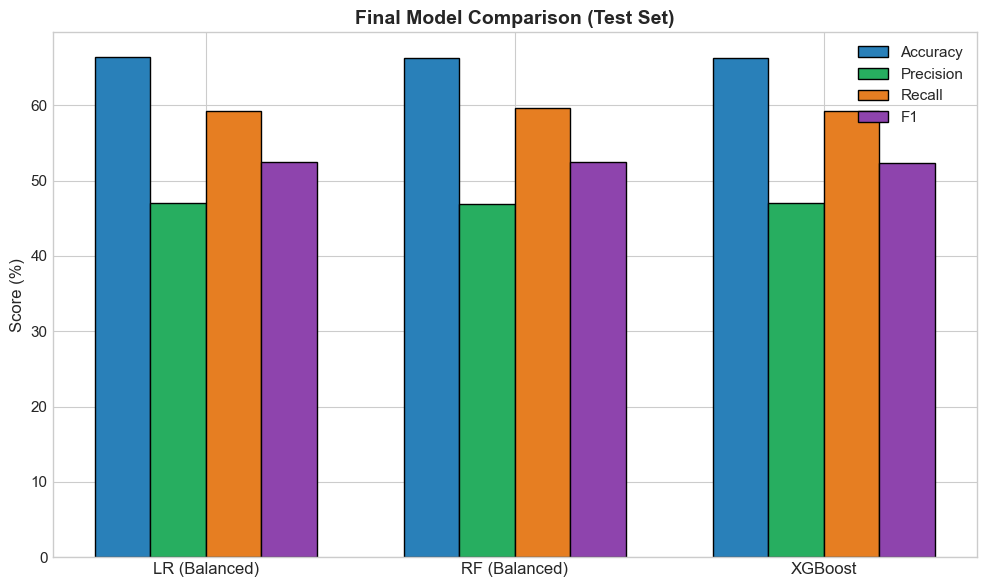


Model Comparison Table (Test Set + 5-Fold CV F1):
        Model  Accuracy  Precision  Recall    F1  CV F1 Mean  CV F1 Std
LR (Balanced)     0.664      0.471   0.592 0.525       0.521      0.006
RF (Balanced)     0.662      0.469   0.597 0.525       0.521      0.009
      XGBoost     0.663      0.470   0.592 0.524       0.522      0.009


In [13]:
# Train advanced models (with class balancing)
models = {
    "LR (Balanced)": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
    "RF (Balanced)": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100, 
        eval_metric="logloss", 
        scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train), 
        random_state=RANDOM_STATE
    )
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    # Use scaled for LR, raw for others
    X_tr = X_train_scaled if "LR" in name else X_train
    X_te = X_test_scaled if "LR" in name else X_test
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    # Cross-validation (F1)
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring="f1")
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "CV F1 Mean": cv_scores.mean(),
        "CV F1 Std": cv_scores.std()
    })

results_df = pd.DataFrame(results)

# Model Comparison Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.18
x = np.arange(len(results_df))

metrics = ["Accuracy", "Precision", "Recall", "F1"]
colors = ["#2980b9", "#27ae60", "#e67e22", "#8e44ad"]

for i, metric in enumerate(metrics):
    ax.bar(x + i*bar_width, results_df[metric]*100, width=bar_width, label=metric, color=colors[i], edgecolor="black")

ax.set_xticks(x + 1.5*bar_width)
ax.set_xticklabels(results_df["Model"], fontsize=12)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("Final Model Comparison (Test Set)", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# Show CV results as table
print("\nModel Comparison Table (Test Set + 5-Fold CV F1):")
display_cols = ["Model", "Accuracy", "Precision", "Recall", "F1", "CV F1 Mean", "CV F1 Std"]
print(results_df[display_cols].to_string(index=False, float_format="{:.3f}".format))

## 12. Feature Importance (Random Forest)

We analyze which pre-launch features are most predictive of success using the Random Forest model.

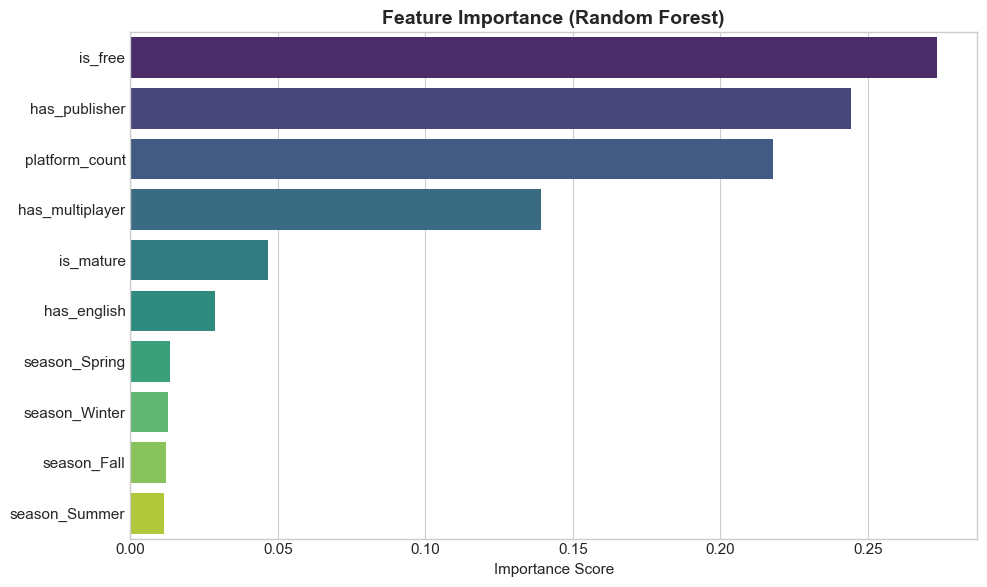

Top 5 Most Predictive Features:
        Feature  Importance
        is_free    0.273337
  has_publisher    0.244323
 platform_count    0.217969
has_multiplayer    0.139200
      is_mature    0.046819


In [14]:
# Feature importance from Random Forest
rf_model = models["RF (Balanced)"]
importances = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importances, palette="viridis")
plt.title("Feature Importance (Random Forest)", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("Top 5 Most Predictive Features:")
print(importances.head(5).to_string(index=False))

## 13. Cross-Validation Stability

We visualize the variance of F1 scores across 5 folds for each model to assess stability.

LR (Balanced) 5-Fold F1: 0.521 ± 0.006


RF (Balanced) 5-Fold F1: 0.521 ± 0.009


XGBoost 5-Fold F1: 0.522 ± 0.009


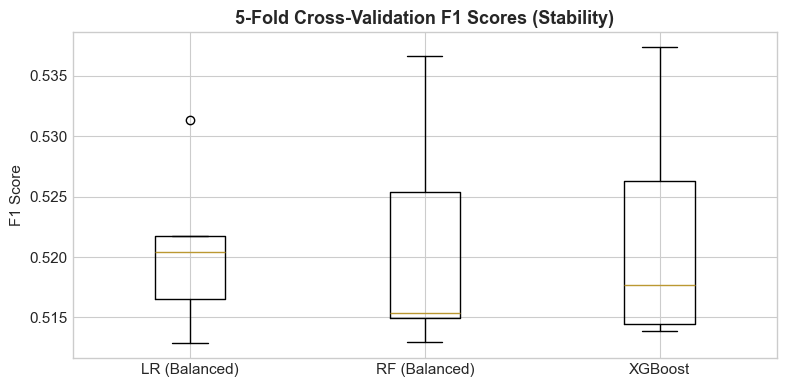

In [15]:
# Cross-validation F1 scores for each model
cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    X_cv = X_train_scaled if "LR" in name else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=skf, scoring="f1")
    cv_results[name] = scores
    print(f"{name} 5-Fold F1: {scores.mean():.3f} ± {scores.std():.3f}")

# Plot CV stability
plt.figure(figsize=(8, 4))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.title("5-Fold Cross-Validation F1 Scores (Stability)", fontsize=13, fontweight="bold")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

## 14. Conclusion

- **Class imbalance** is a major challenge; accuracy alone is misleading.
- **Pre-launch features** (platform, publisher, multiplayer, timing) are predictive, but not as strong as post-launch metrics.
- **Balanced models** reach F1 ≈ 0.52 (vs 0.33 for an unbalanced LR); LR, RF and XGBoost perform almost identically, so the signal in these features — not model capacity — is the limit.
- **Feature importance** highlights pricing (free vs paid), publisher backing and platform count; release season matters little.
- **Cross-validation** confirms model stability.

**Future Work:**
- Incorporate more pre-launch signals (e.g., wishlist counts, social media buzz)
- Use NLP on game descriptions
- Hyperparameter tuning for further gains